
# BERT-Based Multi-Class Text Classification

### Problem Statement
> **Implement a pre-trained BERT model for sentiment analysis or text classification on a sample dataset.**

### Project
This notebook fine-tunes the pre-trained **BERT-base-uncased** model for **multi-class text classification** using the **SMILE Twitter dataset**.

The notebook is designed for a classroom presentation: every major step includes a short explanation, visualizations, examples, and an interpretation of the result.

### Pipeline

**Raw Tweets → Data Cleaning → Exploratory Analysis → BERT Tokenization → Pre-trained BERT → Fine-tuning → Evaluation → New-Tweet Prediction**



## 1. What are we trying to solve?

A tweet contains natural language, but a machine-learning model needs a numerical representation of that language.

For example:

> **"I absolutely loved this exhibition!"**

The goal is to automatically assign the tweet to one of the dataset's classes.

### Why BERT?

Traditional text classification often depends on manually designed features such as word counts or TF-IDF. BERT instead uses a **pre-trained Transformer language model** that has already learned rich language representations from large amounts of text.

We then **fine-tune** BERT on our labelled dataset for the specific classification task.

### Key idea for presentation

> **We are not training BERT from scratch. We start from a pre-trained language model and adapt it to our classification problem.**


In [1]:

# If required in Google Colab/Jupyter, run this once.
# !pip install -q transformers accelerate scikit-learn pandas matplotlib torch

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda



## 2. Load the dataset

The SMILE dataset contains tweets, tweet IDs, and emotion/annotation labels.

We will use the tweet text as the **input feature** and the annotation as the **target label**.

> **Important:** Some rows contain multiple labels such as `happy|surprise`. Since the model below is a single-label classifier, those multi-label rows are removed.


In [2]:

DATA_PATH = "smile-annotations-final.csv"

# Read the dataset. The file has no header, so we assign meaningful names.
df = pd.read_csv(DATA_PATH, header=None, names=["tweet_id", "text", "label"])

print("Original shape:", df.shape)
display(df.head())
print("\nOriginal label distribution:")
display(df["label"].value_counts())


Original shape: (3085, 3)


,tweet_id,text,label
0,611857364396965889,@aandraous @britishmuseum @AndrewsAntonio Merc...,nocode
1,614484565059596288,Dorian Gray with Rainbow Scarf #LoveWins (from...,happy
2,614746522043973632,@SelectShowcase @Tate_StIves ... Replace with ...,happy
3,614877582664835073,@Sofabsports thank you for following me back. ...,happy
4,611932373039644672,@britishmuseum @TudorHistory What a beautiful ...,happy



Original label distribution:


,count
label,
nocode,1572
happy,1137
not-relevant,214
angry,57
surprise,35
sad,32
happy|surprise,11
happy|sad,9
disgust|angry,7


In [3]:

# Basic cleaning
df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()

before = len(df)

# Remove empty tweets
df = df[df["text"].str.len() > 0].copy()

# Keep only single-label examples
single_label_mask = ~df["label"].str.contains(r"\|", regex=True)
df = df[single_label_mask].copy()

# Remove duplicate tweet texts
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {len(df)}")
print(f"Rows removed         : {before - len(df)}")
print("\nFinal classes:")
print(sorted(df["label"].unique()))


Rows before cleaning : 3085
Rows after cleaning  : 3011
Rows removed         : 74

Final classes:
['angry', 'disgust', 'happy', 'nocode', 'not-relevant', 'sad', 'surprise']



## 3. Exploratory Data Analysis

Before training a deep-learning model, we should understand the data.

Two useful questions are:

1. **How many examples are available?**
2. **Are the classes balanced?**

This matters because a model can appear accurate simply by predicting a very common class.


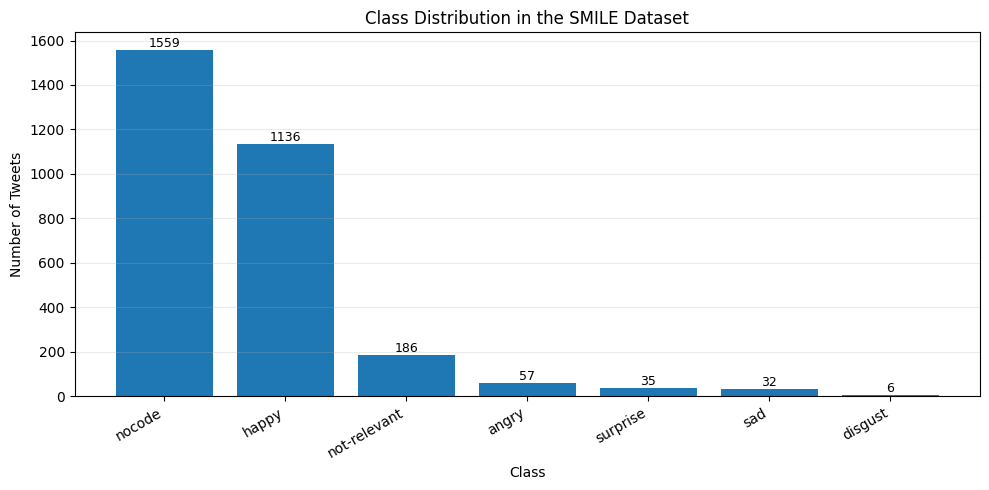

Total usable examples: 3011


In [4]:

# Class distribution
class_counts = df["label"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution in the SMILE Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, str(value),
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("Total usable examples:", len(df))



### What should we notice?

The dataset is **highly imbalanced**. Some classes contain many more examples than others.

For this reason, this notebook uses a **weighted sampler for the training DataLoader**, giving minority classes a better chance of appearing during training.

This is an important point to mention during the viva:

> **Accuracy alone can be misleading on an imbalanced dataset, so we also report macro-F1 and weighted-F1.**



## 4. Look at real examples

Seeing actual tweets makes the classification task easier to understand.

The examples below are taken directly from the supplied dataset.


In [5]:

# Show one example from each class
for label in sorted(df["label"].unique()):
    example = df[df["label"] == label].iloc[0]
    print(f"\n[{label}]")
    print(example["text"])



[angry]
@nationalgallery #AskTheGallery Why do you pay your brilliant staff so poorly?

[disgust]
.@NationalGallery ignores questions on sponsorship fees received from Shell. No surprises. #Artwash https://t.co/sTcbuC1dhz

[happy]
Dorian Gray with Rainbow Scarf #LoveWins (from @britishmuseum http://t.co/Q4XSwL0esu) http://t.co/h0evbTBWRq

[nocode]
@aandraous @britishmuseum @AndrewsAntonio Merci pour le partage! @openwinemap

[not-relevant]
@RAMMuseum Please vote for us as @sainsbury #sidwell's local charity PRT http://t.co/IguyWk5MJT http://t.co/5kPGLNeW4H

[sad]
@BBC_Culture @PlymouthMuseum Oh dear, why not Dame Laura Knight? Surely 'The Beach' should be in this list!

[surprise]
@britishmuseum turquoise eyes!!!



## 5. Prepare labels

Neural networks work with numerical class IDs rather than text labels.

Example:

```text
happy         → 0
nocode        → 1
not-relevant  → 2
...
```

The mapping is created automatically so that the notebook remains robust if the class order changes.


In [6]:

label_encoder = LabelEncoder()

df["label_id"] = label_encoder.fit_transform(df["label"])

label_names = list(label_encoder.classes_)
num_labels = len(label_names)

label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for i, label in enumerate(label_names)}

print("Label mapping:")
for i, label in id2label.items():
    print(f"{i}: {label}")

print("\nNumber of classes:", num_labels)


Label mapping:
0: angry
1: disgust
2: happy
3: nocode
4: not-relevant
5: sad
6: surprise

Number of classes: 7



## 6. Train / validation / test split

We divide the data into:

- **Training set:** used to fine-tune BERT
- **Validation set:** used during training to monitor performance
- **Test set:** kept aside for the final evaluation

We use **stratification** so that each split keeps approximately the same class proportions.


In [7]:
# First split: 80% training, 20% temporary
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label_id"]
)

# Second split: 10% validation, 10% test
# Stratification can fail because of extremely rare classes.
try:
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED,
        stratify=temp_df["label_id"]
    )

except ValueError:
    print("Stratified split failed because some classes are too rare.")
    print("Using a random split for validation and test sets.")

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=SEED
    )

print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples   :", len(test_df))

Stratified split failed because some classes are too rare.
Using a random split for validation and test sets.
Training samples  : 2408
Validation samples: 301
Testing samples   : 302



## 7. BERT Tokenization

BERT cannot directly consume raw strings.

The **BERT tokenizer** converts each sentence into:

- **Input IDs** – numerical IDs representing tokens
- **Attention Mask** – tells BERT which positions are real tokens and which are padding

For example:

```text
"I loved this museum!"
        ↓
BERT Tokenizer
        ↓
[CLS] I loved this museum ! [SEP]
        ↓
Input IDs + Attention Mask
```

The `[CLS]` token is especially important for classification because its final representation is used as a summary representation of the sequence.


In [8]:

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample_text = "I absolutely loved this exhibition!"
sample_tokens = tokenizer.tokenize(sample_text)
sample_encoded = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

print("Example text:")
print(sample_text)

print("\nTokens:")
print(sample_tokens)

print("\nFirst 20 input IDs:")
print(sample_encoded["input_ids"][0][:20].tolist())

print("\nFirst 20 attention-mask values:")
print(sample_encoded["attention_mask"][0][:20].tolist())


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Example text:
I absolutely loved this exhibition!

Tokens:
['i', 'absolutely', 'loved', 'this', 'exhibition', '!']

First 20 input IDs:
[101, 1045, 7078, 3866, 2023, 4538, 999, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

First 20 attention-mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



## 8. Create a PyTorch Dataset

We now wrap the tweets and their labels in a PyTorch Dataset.

Each item returned by the Dataset contains:

```text
input_ids
attention_mask
labels
```

These tensors are exactly what the BERT sequence-classification model expects.


In [9]:

class TweetDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TweetDataset(train_df, tokenizer, MAX_LEN)
val_dataset = TweetDataset(val_df, tokenizer, MAX_LEN)
test_dataset = TweetDataset(test_df, tokenizer, MAX_LEN)

print("Dataset objects created successfully.")


Dataset objects created successfully.



## 9. Handle class imbalance

The training distribution is uneven, so we use a **WeightedRandomSampler**.

The idea is simple:

> Rare classes receive higher sampling weights, while very common classes receive lower weights.

This does not create new text; it changes how training examples are selected.


In [10]:

train_counts = train_df["label_id"].value_counts().sort_index()

# Inverse-frequency class weights
class_weights = 1.0 / torch.tensor(
    train_counts.values, dtype=torch.float
)

sample_weights = torch.tensor(
    [class_weights[label] for label in train_df["label_id"]],
    dtype=torch.double
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches   :", len(test_loader))


Training batches  : 151
Validation batches: 19
Testing batches   : 19



## 10. Load the pre-trained BERT model

Here is the central step.

We load:

> **`bert-base-uncased`**

and attach a classification head with one output neuron per class.

### Architecture

```text
Input Tweet
     ↓
BERT Tokenizer
     ↓
Pre-trained BERT Encoder
     ↓
[CLS] Representation
     ↓
Classification Head
     ↓
Class Probabilities
```

The original BERT language representation is reused and then **fine-tuned** for our dataset.


In [11]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

model = model.to(DEVICE)

print("Model:", MODEL_NAME)
print("Number of classes:", num_labels)
print("Parameters:", f"{model.num_parameters():,}")


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Number of classes: 7
Parameters: 109,487,623



## 11. Training configuration

For fine-tuning, we use:

- **Optimizer:** AdamW
- **Learning rate:** `2e-5`
- **Epochs:** `3`
- **Batch size:** `16`
- **Maximum sequence length:** `128`
- **Scheduler:** linear warmup/decay

A small learning rate is preferred because BERT already contains useful pre-trained representations. We want to adapt them carefully rather than make large updates.


In [12]:

EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.10

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print("Total optimization steps:", total_steps)
print("Warmup steps:", warmup_steps)


Total optimization steps: 453
Warmup steps: 45



## 12. Training and validation loop

For every batch:

1. Tokenized text is sent to BERT.
2. BERT produces logits.
3. Loss is calculated.
4. Backpropagation computes gradients.
5. AdamW updates the weights.
6. The learning-rate scheduler updates the learning rate.

After every epoch, the model is evaluated on the validation set.


In [13]:

def run_epoch(model, loader, optimizer=None, scheduler=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

        total_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return avg_loss, accuracy, macro_f1, weighted_f1, all_labels, all_preds


history = []

best_val_f1 = -1.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_macro_f1, train_weighted_f1, _, _ = run_epoch(
        model, train_loader, optimizer, scheduler
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1, _, _ = run_epoch(
        model, val_loader
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_acc,
        "val_accuracy": val_acc,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_macro_f1,
        "train_weighted_f1": train_weighted_f1,
        "val_weighted_f1": val_weighted_f1
    })

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f}"
    )

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

# Restore best validation model
if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
display(history_df)


Epoch 1/3 | Train Loss: 1.4989 | Val Loss: 1.2422 | Val Acc: 0.5814 | Val Macro-F1: 0.3364
Epoch 2/3 | Train Loss: 0.5233 | Val Loss: 0.8399 | Val Acc: 0.7143 | Val Macro-F1: 0.3777
Epoch 3/3 | Train Loss: 0.2843 | Val Loss: 0.7286 | Val Acc: 0.7575 | Val Macro-F1: 0.4994


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1
0,1,1.498892,1.242212,0.462625,0.581395,0.446800,0.336366,0.445898,0.630926
1,2,0.523285,0.839938,0.863372,0.714286,0.863107,0.377705,0.859825,0.748053
2,3,0.284256,0.728622,0.926910,0.757475,0.923979,0.499370,0.925778,0.771622



## 13. Training curves

These graphs help us answer an important question:

> **Is the model learning, and is it beginning to overfit?**

We plot training and validation loss separately from accuracy/F1 so that the trends are easy to interpret.


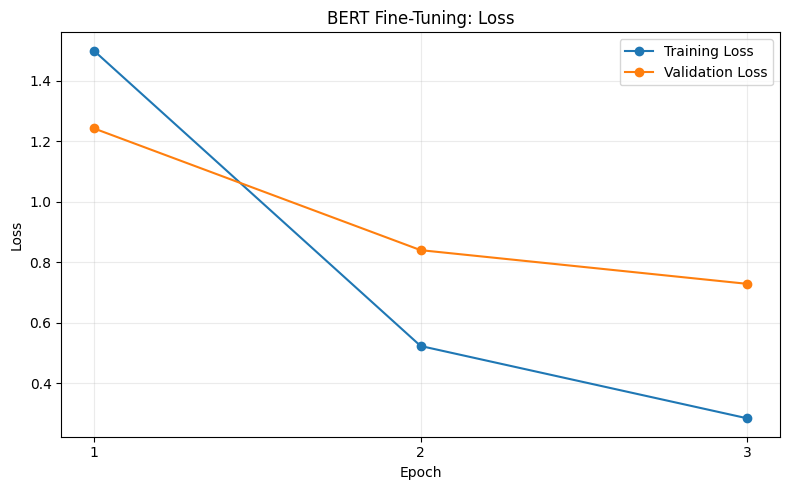

In [14]:

# Loss curve
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.title("BERT Fine-Tuning: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


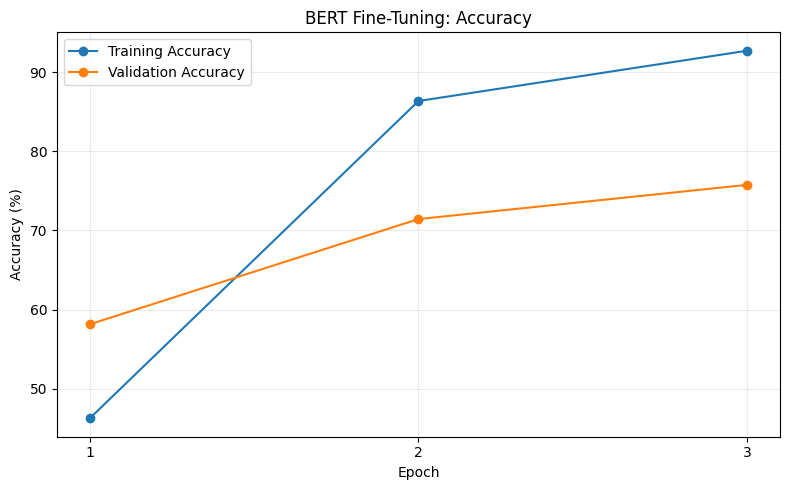

In [15]:

# Accuracy curve
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_accuracy"] * 100,
         marker="o", label="Training Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"] * 100,
         marker="o", label="Validation Accuracy")
plt.title("BERT Fine-Tuning: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


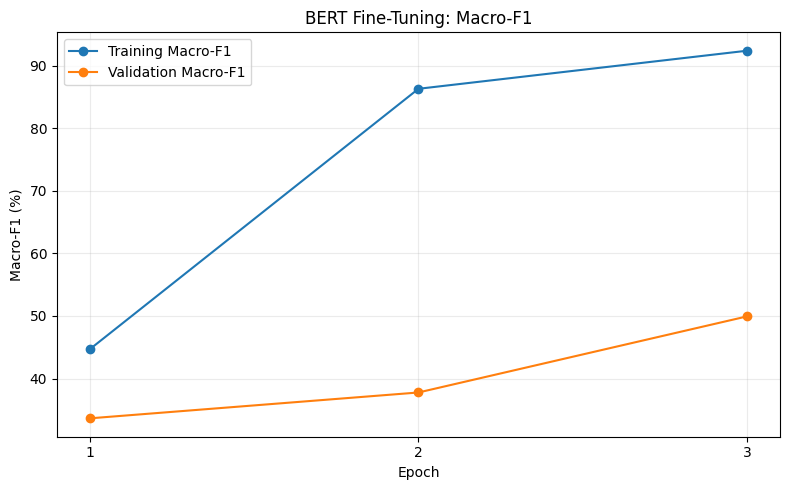

In [16]:

# Macro-F1 curve
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"] * 100,
         marker="o", label="Training Macro-F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"] * 100,
         marker="o", label="Validation Macro-F1")
plt.title("BERT Fine-Tuning: Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1 (%)")
plt.xticks(history_df["epoch"])
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()



## 14. Final evaluation on the test set

The test set has not been used to update model weights.

This gives us a cleaner estimate of how the fine-tuned BERT model performs on unseen tweets.

We report:

- **Accuracy**
- **Macro-F1** – gives equal importance to every class
- **Weighted-F1** – accounts for class frequency
- **Classification report**
- **Confusion matrix**


In [17]:

test_loss, test_acc, test_macro_f1, test_weighted_f1, y_true, y_pred = run_epoch(
    model, test_loader
)

print("FINAL TEST RESULTS")
print("=" * 55)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc * 100:.2f}%")
print(f"Test Macro-F1  : {test_macro_f1 * 100:.2f}%")
print(f"Test Weighted-F1: {test_weighted_f1 * 100:.2f}%")


FINAL TEST RESULTS
Test Loss      : 0.7233
Test Accuracy  : 76.16%
Test Macro-F1  : 54.75%
Test Weighted-F1: 76.93%


In [18]:

print("Classification Report")
print("=" * 75)

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_labels)),
        target_names=label_names,
        zero_division=0,
        digits=3
    )
)


Classification Report
              precision    recall  f1-score   support

       angry      0.571     0.800     0.667         5
     disgust      0.000     0.000     0.000         1
       happy      0.818     0.903     0.858       124
      nocode      0.851     0.715     0.777       144
not-relevant      0.241     0.333     0.280        21
         sad      0.500     0.500     0.500         2
    surprise      1.000     0.600     0.750         5

    accuracy                          0.762       302
   macro avg      0.569     0.550     0.547       302
weighted avg      0.788     0.762     0.769       302



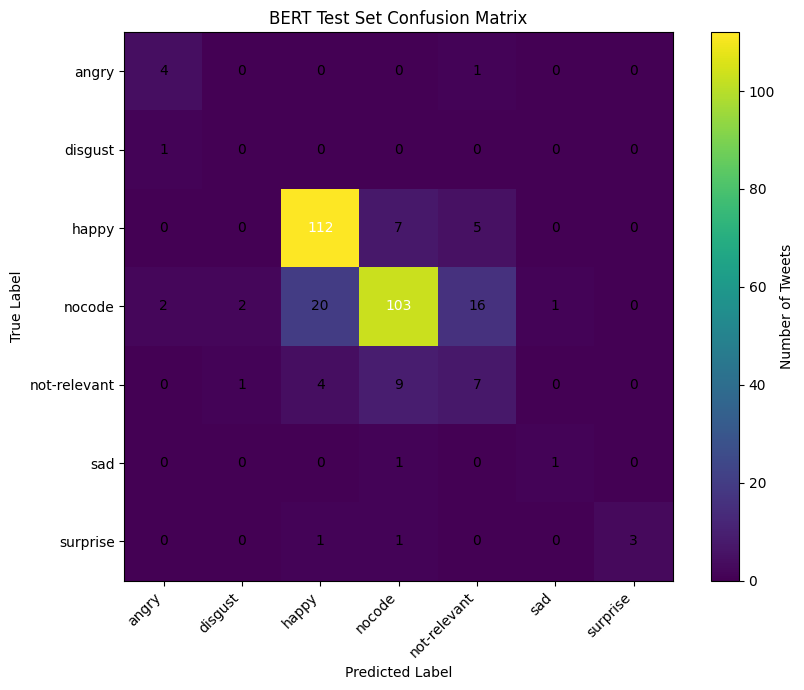

In [19]:

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))

plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation="nearest")
plt.title("BERT Test Set Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(num_labels), label_names, rotation=45, ha="right")
plt.yticks(range(num_labels), label_names)
plt.colorbar(label="Number of Tweets")

threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()
plt.show()



### How to explain the confusion matrix

- **Diagonal cells** = correctly classified tweets.
- **Off-diagonal cells** = misclassifications.
- A strong diagonal indicates that the model is distinguishing the classes well.
- Errors between semantically similar classes are expected in natural-language classification.

Because this dataset is imbalanced, look at the confusion matrix together with **Macro-F1 and per-class F1**, rather than judging the model only by accuracy.



## 15. Per-class performance

A bar chart makes it easier to see which classes the model handles well and which classes remain difficult.


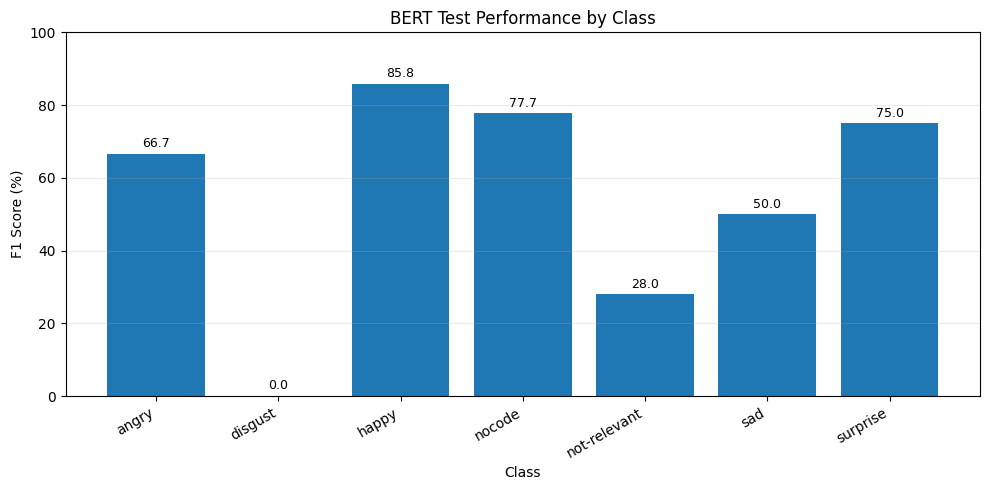

In [20]:

report = classification_report(
    y_true,
    y_pred,
    labels=list(range(num_labels)),
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

per_class_f1 = [report[label]["f1-score"] * 100 for label in label_names]

plt.figure(figsize=(10, 5))
bars = plt.bar(label_names, per_class_f1)
plt.title("BERT Test Performance by Class")
plt.xlabel("Class")
plt.ylabel("F1 Score (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, value + 1,
             f"{value:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()



## 16. Real-world inference

This is the most presentation-friendly part of the project.

The trained model can receive a **new tweet that it has never seen before** and return the predicted class and confidence.

This demonstrates the complete end-to-end application of BERT.


In [21]:

def predict_text(text, top_k=3):
    model.eval()

    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    encoding = {key: value.to(DEVICE) for key, value in encoding.items()}

    with torch.no_grad():
        outputs = model(**encoding)
        probabilities = torch.softmax(outputs.logits, dim=1)[0]

    values, indices = torch.topk(
        probabilities,
        k=min(top_k, num_labels)
    )

    results = [
        (id2label[int(idx)], float(prob))
        for prob, idx in zip(values.cpu(), indices.cpu())
    ]

    return results


examples = [
    "I absolutely loved this exhibition!",
    "Why is the service so terrible?",
    "I am really looking forward to visiting tomorrow.",
    "The museum is open from 10am to 5pm."
]

for text in examples:
    results = predict_text(text)
    print("\nTweet:", text)
    print("Predictions:")
    for label, probability in results:
        print(f"  {label:15s} {probability * 100:6.2f}%")



Tweet: I absolutely loved this exhibition!
Predictions:
  happy            91.68%
  surprise          3.29%
  nocode            2.01%

Tweet: Why is the service so terrible?
Predictions:
  angry            53.60%
  surprise         24.97%
  happy             5.16%

Tweet: I am really looking forward to visiting tomorrow.
Predictions:
  happy            85.25%
  nocode            5.47%
  surprise          4.10%

Tweet: The museum is open from 10am to 5pm.
Predictions:
  nocode           65.46%
  not-relevant     13.52%
  happy             6.63%



## 17. Confidence visualization for a new tweet

Instead of only displaying the predicted label, we can visualize the model's top predictions.

This makes the inference stage easier to explain during the presentation.


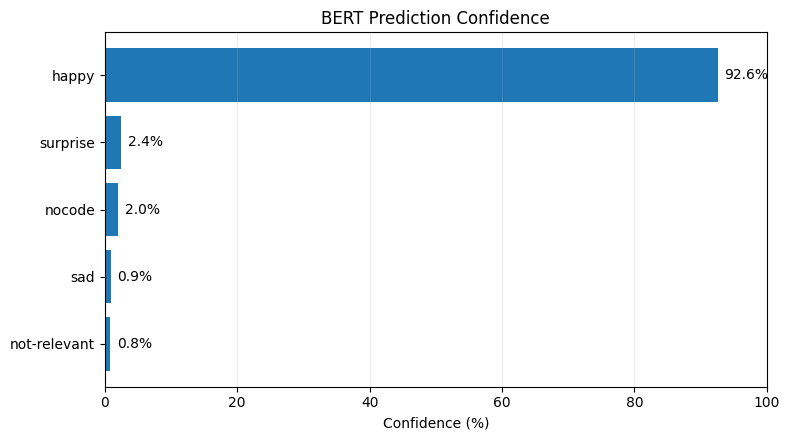

Input: This was an amazing experience, I really enjoyed it!
Predicted class: happy
Confidence: 92.58%


In [22]:

def plot_prediction(text, top_k=5):
    results = predict_text(text, top_k=top_k)
    labels = [x[0] for x in results]
    probs = [x[1] * 100 for x in results]

    plt.figure(figsize=(8, 4.5))
    bars = plt.barh(labels[::-1], probs[::-1])
    plt.title("BERT Prediction Confidence")
    plt.xlabel("Confidence (%)")
    plt.xlim(0, 100)
    plt.grid(axis="x", alpha=0.25)

    for bar, value in zip(bars, probs[::-1]):
        plt.text(
            value + 1,
            bar.get_y() + bar.get_height()/2,
            f"{value:.1f}%",
            va="center"
        )

    plt.tight_layout()
    plt.show()

    print("Input:", text)
    print("Predicted class:", results[0][0])
    print("Confidence:", f"{results[0][1] * 100:.2f}%")

plot_prediction("This was an amazing experience, I really enjoyed it!")



## 18. Save the fine-tuned model

Saving the tokenizer and model allows us to reuse the trained BERT model later without training from scratch.


In [23]:

SAVE_DIR = "bert_smile_text_classifier"

os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"Model and tokenizer saved to: {SAVE_DIR}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: bert_smile_text_classifier



# 19. Final Summary

### What we implemented

1. Loaded the SMILE Twitter dataset.
2. Cleaned the data and retained single-label examples.
3. Explored the class distribution.
4. Encoded text labels into numerical IDs.
5. Split the data into training, validation, and test sets.
6. Used the **BERT tokenizer** to convert tweets into tensors.
7. Loaded the **pre-trained `bert-base-uncased`** model.
8. Fine-tuned BERT for multi-class text classification.
9. Used weighted sampling to reduce the effect of class imbalance.
10. Evaluated the model using Accuracy, Macro-F1, Weighted-F1 and a Confusion Matrix.
11. Tested the model on completely new text.
12. Saved the fine-tuned model for future use.

### Final takeaway

> **BERT provides powerful pre-trained language representations, and fine-tuning allows those representations to be adapted to a specific text-classification task.**

### Presentation flow

**Problem → Dataset → Cleaning → EDA → Tokenization → BERT Architecture → Fine-tuning → Evaluation → Confusion Matrix → Real-Time Prediction → Conclusion**



# 20. Viva / Presentation Quick Answers

### Why BERT?
BERT understands contextual relationships between words using Transformer-based self-attention, making it strong for language understanding tasks.

### Why use a pre-trained model?
Training BERT from scratch requires enormous data and computation. A pre-trained BERT already contains useful language representations, so fine-tuning is much more efficient.

### What is fine-tuning?
Fine-tuning means continuing training of the pre-trained BERT model on our labelled dataset so that it learns the specific classification task.

### What is the attention mask?
It tells BERT which token positions are actual input and which positions are padding.

### Why `bert-base-uncased`?
It is a standard BERT-base model with uncased English vocabulary. Lowercasing reduces unnecessary distinctions between uppercase and lowercase forms.

### Why Macro-F1?
The dataset is imbalanced. Macro-F1 gives every class equal importance, so minority-class performance is not hidden by a large majority class.

### Why not train BERT from scratch?
It would require substantially more data, computation, and training time. Transfer learning gives strong language representations with much less task-specific data.

### What is the role of `[CLS]`?
BERT uses the final representation associated with `[CLS]` as a sequence-level representation for classification.

### What does the confusion matrix show?
It shows how often each true class was predicted as each class. The diagonal represents correct predictions.

### What is the biggest limitation?
The dataset is highly imbalanced, and some classes have very few examples. Therefore, minority-class metrics should be interpreted carefully.
